# ALS

This notebook trains an **Alternating Least Squares (ALS)** model to serve as a **baseline** recommender system.

ALS is a classic collaborative filtering algorithm that learns **latent factors** for users and items by factorizing the implicit feedback matrix. In our case, feedback is based on the **watch ratio**, and we define an interaction as "liked" if `watch_ratio > 2`, following the KuaiRec paper.

This model is **purely interaction-based** (no content or features), which makes it fast to train and useful for benchmarking. While simple, ALS can still capture meaningful patterns in large-scale user-item interaction data.

We will:
- Prepare the data and construct a sparse matrix.
- Train the ALS model on implicit signals.
- Evaluate its performance using ranking metrics like Precision@K, Recall@K, and NDCG@K.

This helps set a reference point to compare more complex models later.


In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares
from tqdm import tqdm

from src.metrics import RecoMetrics
from src.utils import *

---

# Data processing

This section prepares the training and validation datasets for the ALS model:

- **Step 1:** Selects only the necessary columns: `user_id`, `video_id`, and `watch_ratio`.
- **Step 2:** Adds a `liked` flag — a binary label where a video is considered **"liked"** if `watch_ratio > 2`, as defined in the KuaiRec paper.
- **Step 3:** Constructs a **sparse interaction matrix** where each cell contains a clipped `watch_ratio` (capped at 2). This matrix is used as the input for ALS, which treats it as implicit feedback.

Clipping values at 2 avoids overweighting extreme watch times and ensures consistent scaling for ALS training.


In [2]:
COLS = ["user_id", "video_id", "watch_ratio"]

X_train = read_matrix("big", "big_matrix")[COLS]
X_val = read_matrix("small", "small_matrix")[COLS]

# -------------------------
# Adding like
# -------------------------
X_train['liked'] = (X_train['watch_ratio'] > 2).astype(float)
X_val['liked'] = (X_val['watch_ratio'] > 2).astype(float)

# Implicit matrix (items x users)
sparse_matrix = csr_matrix(
    (X_train['watch_ratio'].clip(upper=2), (X_train['user_id'], X_train['video_id']))
)

--- Reading big matrix ---
Loading...
Cleaning...
0.08% of the data has been filtered out
--- Readed in 18.7988s ---
--- Reading small matrix ---
Loading...
Cleaning...
0.04% of the data has been filtered out
--- Readed in 6.4709s ---


---

# Training

We just train add some regularization

In [7]:
# -------------------------
# Train ALS model
# -------------------------
model = AlternatingLeastSquares(regularization=0.01, calculate_training_loss=True)
model.fit(sparse_matrix)

/home/hpn4/epita/inge/ing2/rema/project/env/lib/python3.11/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 16 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/15 [00:00<?, ?it/s]

---

# Evaluating

For each user in the validation set:

- It retrieves the **ground-truth liked items** from validation data.
- Skips users with no positive interactions (no "likes").
- Filters out items the user has already seen in the training set.
- Computes the **top-K recommendations** based on the dot product between user and item factors.
- Adds the results to the metric tracker for later aggregation and plotting.

Evaluating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1411/1411 [01:14<00:00, 18.95it/s]



Metrics @ K=5:
  Precision@K: 0.0109
  Recall@K: 0.0004
  MAP@K: 0.0049
  NDCG@K: 0.0107
  HitRate@K: 0.0532

Metrics @ K=10:
  Precision@K: 0.0108
  Recall@K: 0.0007
  MAP@K: 0.0033
  NDCG@K: 0.0107
  HitRate@K: 0.0978

Metrics @ K=20:
  Precision@K: 0.0115
  Recall@K: 0.0016
  MAP@K: 0.0022
  NDCG@K: 0.0112
  HitRate@K: 0.1857

Metrics @ K=50:
  Precision@K: 0.0132
  Recall@K: 0.0047
  MAP@K: 0.0014
  NDCG@K: 0.0130
  HitRate@K: 0.4118

Metrics @ K=100:
  Precision@K: 0.0137
  Recall@K: 0.0090
  MAP@K: 0.0011
  NDCG@K: 0.0146
  HitRate@K: 0.5826


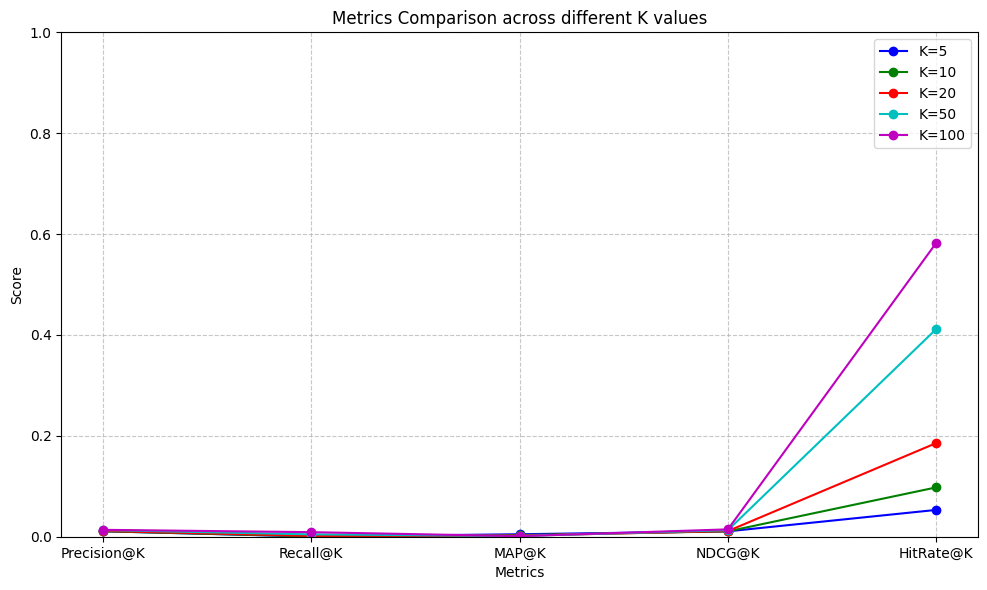

In [12]:
# ------------------------
# Initialize metrics containers
# ------------------------
reco = RecoMetrics()

# ------------------------
# Evaluate for each user in validation
# ------------------------
for user_id in tqdm(X_val['user_id'].unique(), desc="Evaluating"):
    # Filter rows based on user_id and liked == 1 in one step
    seen_eval = X_val[(X_val['user_id'] == user_id) & (X_val["liked"] == 1)]['video_id'].values

    # If no liked items, skip this user
    if len(seen_eval) == 0:
        continue

    seen_train = X_train[(X_train['user_id'] == user_id) & (X_train["liked"] == 1)]['video_id'].values
    
    # Get the user's predicted scores for all items
    predicted_scores = model.user_factors[user_id] @ model.item_factors.T
    filtered_predicted_scores = np.delete(predicted_scores, seen_train)

    # Get the top-K recommended items based on predicted scores
    recommended_items = np.argsort(filtered_predicted_scores)[::-1]  # Indices of top-K items

    reco.add_evaluation(seen_eval, recommended_items)

reco.plot()

---

We zoom in a little to grasp what's going on with other metrics

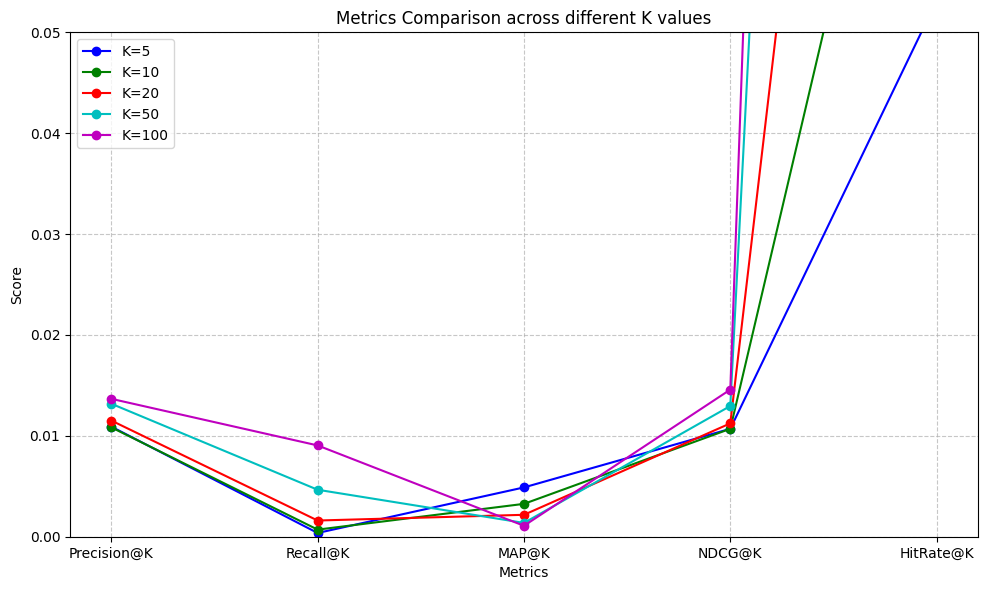

In [13]:
reco.plot(False, 0.05)

---

# Evaluation Metrics – Interpretation

These metrics evaluate how well the ALS model ranks relevant videos for each user. Here's what each means:

- **Precision@K (~0.014)**: On average, only 1.4% of the top recommended items are actually relevant (liked). This is low, suggesting the model recommends mostly irrelevant items.
  
- **Recall@K (~0.01)**: The model retrieves just 1% of the total relevant items per user. It's missing the vast majority of good content, which indicates weak coverage of the user’s true preferences.

- **MAP@K (~0.005)**: The low Mean Average Precision suggests that relevant items (when present) appear late in the recommendation list. So, even when the model gets it right, it doesn’t rank the good items high enough.

- **NDCG@K (~0.014)**: Similar to MAP but emphasizes the order of recommendations. A low score shows that relevance isn’t concentrated toward the top of the list.

- **HitRate@K (~0.6)**: About 60% of users get **at least one correct recommendation** in their top-K. While this is better than the other metrics, it still means the model fails for 40% of users.